In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
def histogram_equalization_gray(image):
  name, ext = os.path.splitext(image)
  output_name = name + "_equalized" + ext
  gray = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  maxpix = int(np.max(gray))
  minpix = int(np.min(gray))
  intensity = np.array([i for i in range(maxpix+1)])
  histarray = np.zeros((maxpix+1,))
  for i in range(len(gray)):
    for j in range(len(gray[0])):
      histarray[gray[i][j]]  += 1
  histarray = histarray/(gray.shape[0]*gray.shape[1])
  cumhistarray = np.zeros((maxpix+1,))
  label = np.zeros((maxpix+1,), dtype=int)
  cumhistarray[0] = histarray[0]
  for i in range(1,maxpix+1):
    cumhistarray[i] = histarray[i]+cumhistarray[i-1]
  for i in range(maxpix+1):
    if cumhistarray[i]!=0:
      smin=cumhistarray[i]
      break
  for i in range(maxpix):
    label[i] = np.round((cumhistarray[i]-smin)/(1-smin)*maxpix + 0.5)
  label[maxpix] = maxpix
  newhistarray = np.zeros((maxpix+1,))
  for i in range(len(newhistarray)):
    newhistarray[label[i]] += histarray[i]
# Original histogram
  plt.figure(figsize=(10, 4))
  plt.bar(intensity, histarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Histogram")
  plt.tight_layout()

  histogram_name = name + "_original_histogram.png"
  plt.savefig(histogram_name, dpi=300, bbox_inches="tight")
  plt.show()


# Equalized histogram
  plt.figure(figsize=(10, 4))
  plt.bar(intensity, newhistarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Equalized Histogram")
  plt.tight_layout()

  histogram_name = name + "_equalized_histogram.png"
  plt.savefig(histogram_name, dpi=300, bbox_inches="tight")
  plt.show()

  modified = np.zeros_like(gray)
  for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        modified[i][j] = label[gray[i][j]]
  cv2.imwrite(output_name, modified)
def histogram_matching_gray(image1,image2) :
  name, ext = os.path.splitext(image1)
  output_name = name + "_matched" + ext
  gray1 = cv2.imread(image1, cv2.IMREAD_GRAYSCALE)
  maxpix1 = int(np.max(gray1))
  minpix1 = int(np.min(gray1))
  intensity1 = np.array([i for i in range(maxpix1+1)])
  histarray1 = np.zeros((maxpix1+1,))
  gray2 = cv2.imread(image2, cv2.IMREAD_GRAYSCALE)
  maxpix2 = int(np.max(gray2))
  minpix2 = int(np.min(gray2))
  intensity2 = np.array([i for i in range(maxpix2+1)])
  histarray2 = np.zeros((maxpix2+1,))
  for i in range(len(gray1)):
    for j in range(len(gray1[0])):
      histarray1[gray1[i][j]]  += 1
  histarray1 = histarray1/(gray1.shape[0]*gray1.shape[1])
  cumhistarray1 = np.zeros((maxpix1+1,))
  cumhistarray1[0] = histarray1[0]
  for i in range(1,maxpix1+1):
    cumhistarray1[i] = histarray1[i]+cumhistarray1[i-1]

  for i in range(len(gray2)):
    for j in range(len(gray2[0])):
      histarray2[gray2[i][j]]  += 1
  histarray2 = histarray2/(gray2.shape[0]*gray2.shape[1])
  cumhistarray2 = np.zeros((maxpix2+1,))
  cumhistarray2[0] = histarray2[0]
  for i in range(1,maxpix2+1):
    cumhistarray2[i] = histarray2[i]+cumhistarray2[i-1]
  label = np.zeros((maxpix1+1,), dtype=int)
  for i in range(maxpix1+1):
    labels=0
    dist = 1e9
    for j in range(maxpix2+1):
      if abs(cumhistarray1[i]-cumhistarray2[j]) < dist:
        dist = abs(cumhistarray1[i]-cumhistarray2[j])
        labels = j
    label[i] = labels
  newhistarray = np.zeros(max(maxpix1+1,maxpix2+1),)
  for i in range(maxpix1+1):
    newhistarray[label[i]] += histarray1[i]
  plt.figure(figsize=(10, 6))
  plt.bar(intensity1, histarray1, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Image 1 Histogram")
  plt.tight_layout()

  plt.savefig(name + "_original1_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()


# Original image 2 histogram
  name2, ext2 = os.path.splitext(image2)

  plt.figure(figsize=(10, 6))
  plt.bar(intensity2, histarray2, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Image 2 Histogram")
  plt.tight_layout()

  plt.savefig(name2 + "_original2_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()


# Matched image 1 histogram
  plt.figure(figsize=(10, 6))
  intensity_new = np.arange(len(newhistarray))
  plt.bar(intensity_new, newhistarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Matched Image 1 Histogram")
  plt.tight_layout()

  plt.savefig(name + "_matched_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()
  modified = np.zeros_like(gray1)
  for i in range(gray1.shape[0]):
    for j in range(gray1.shape[1]):
        modified[i][j] = label[gray1[i][j]]
  cv2.imwrite(output_name, modified)

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def histogram_equalization_RGB(image):
  name, ext = os.path.splitext(image)
  output_name = name + "_equalized" + ext
  imag = cv2.imread(image)
  rgb = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
  hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
  H, S, gray = cv2.split(hsv)
  maxpix = int(np.max(gray))
  minpix = int(np.min(gray))
  intensity = np.array([i for i in range(maxpix+1)])
  histarray = np.zeros((maxpix+1,))
  for i in range(len(gray)):
    for j in range(len(gray[0])):
      histarray[gray[i][j]]  += 1
  histarray = histarray/(gray.shape[0]*gray.shape[1])
  cumhistarray = np.zeros((maxpix+1,))
  label = np.zeros((maxpix+1,), dtype=int)
  cumhistarray[0] = histarray[0]
  for i in range(1,maxpix+1):
    cumhistarray[i] = histarray[i]+cumhistarray[i-1]
  for i in range(maxpix+1):
    if cumhistarray[i]!=0:
      smin=cumhistarray[i]
      break
  for i in range(maxpix):
    label[i] = np.round((cumhistarray[i]-smin)/(1-smin)*maxpix + 0.5)
  label[maxpix] = maxpix
  newhistarray = np.zeros((maxpix+1,))
  for i in range(len(newhistarray)):
    newhistarray[label[i]] += histarray[i]
# Original histogram
  plt.figure(figsize=(10, 4))
  plt.bar(intensity, histarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Histogram")
  plt.tight_layout()

  histogram_name = name + "_original_histogram.png"
  plt.savefig(histogram_name, dpi=300, bbox_inches="tight")
  plt.show()


  # Equalized histogram
  plt.figure(figsize=(10, 4))
  plt.bar(intensity, newhistarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Equalized Histogram")
  plt.tight_layout()

  histogram_name = name + "_equalized_histogram.png"
  plt.savefig(histogram_name, dpi=300, bbox_inches="tight")
  plt.show()
  modified = np.zeros_like(gray)
  for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        modified[i][j] = label[gray[i][j]]
  hsv_new = cv2.merge((H, S, modified))
  rgb_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2RGB)
  cv2.imwrite(
    output_name,
    cv2.cvtColor(rgb_new, cv2.COLOR_RGB2BGR)
)
def histogram_matching_RGB(image1,image2) :
  name, ext = os.path.splitext(image1)
  output_name = name + "_matched" + ext
  imag1 = cv2.imread(image1)
  imag2 = cv2.imread(image2)
  rgb1 = cv2.cvtColor(imag1, cv2.COLOR_BGR2RGB)
  hsv1 = cv2.cvtColor(rgb1, cv2.COLOR_RGB2HSV)
  H1, S1, gray1 = cv2.split(hsv1)
  rgb2 = cv2.cvtColor(imag2, cv2.COLOR_BGR2RGB)
  hsv2 = cv2.cvtColor(rgb2, cv2.COLOR_RGB2HSV)
  H2, S2, gray2 = cv2.split(hsv2)
  maxpix1 = int(np.max(gray1))
  minpix1 = int(np.min(gray1))
  intensity1 = np.array([i for i in range(maxpix1+1)])
  histarray1 = np.zeros((maxpix1+1,))

  maxpix2 = int(np.max(gray2))
  minpix2 = int(np.min(gray2))
  intensity2 = np.array([i for i in range(maxpix2+1)])
  histarray2 = np.zeros((maxpix2+1,))
  for i in range(len(gray1)):
    for j in range(len(gray1[0])):
      histarray1[gray1[i][j]]  += 1
  histarray1 = histarray1/(gray1.shape[0]*gray1.shape[1])
  cumhistarray1 = np.zeros((maxpix1+1,))
  cumhistarray1[0] = histarray1[0]
  for i in range(1,maxpix1+1):
    cumhistarray1[i] = histarray1[i]+cumhistarray1[i-1]

  for i in range(len(gray2)):
    for j in range(len(gray2[0])):
      histarray2[gray2[i][j]]  += 1
  histarray2 = histarray2/(gray2.shape[0]*gray2.shape[1])
  cumhistarray2 = np.zeros((maxpix2+1,))
  cumhistarray2[0] = histarray2[0]
  for i in range(1,maxpix2+1):
    cumhistarray2[i] = histarray2[i]+cumhistarray2[i-1]
  label = np.zeros((maxpix1+1,), dtype=int)
  for i in range(maxpix1+1):
    labels=0
    dist = 1e9
    for j in range(maxpix2+1):
      if abs(cumhistarray1[i]-cumhistarray2[j]) < dist:
        dist = abs(cumhistarray1[i]-cumhistarray2[j])
        labels = j
    label[i] = labels
  newhistarray = np.zeros(max(maxpix1+1,maxpix2+1),)
  for i in range(maxpix1+1):
    newhistarray[label[i]] += histarray1[i]
  plt.figure(figsize=(10, 6))
  plt.bar(intensity1, histarray1, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Image 1 Histogram")
  plt.tight_layout()

  plt.savefig(name + "_original1_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()


# Original image 2 histogram
  name2, ext2 = os.path.splitext(image2)

  plt.figure(figsize=(10, 6))
  plt.bar(intensity2, histarray2, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Original Image 2 Histogram")
  plt.tight_layout()

  plt.savefig(name2 + "_original2_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()


# Matched image 1 histogram
  plt.figure(figsize=(10, 6))
  intensity_new = np.arange(len(newhistarray))
  plt.bar(intensity_new, newhistarray, width=1)
  plt.xlabel("Intensity")
  plt.ylabel("Frequency")
  plt.title("Matched Image 1 Histogram")
  plt.tight_layout()

  plt.savefig(name + "_matched_histogram.png", dpi=300, bbox_inches="tight")
  plt.show()
  modified = np.zeros_like(gray1)
  for i in range(gray1.shape[0]):
    for j in range(gray1.shape[1]):
        modified[i][j] = label[gray1[i][j]]
  hsv_new = cv2.merge((H1, S1, modified))
  rgb_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2RGB)
  cv2.imwrite(
    output_name,
    cv2.cvtColor(rgb_new, cv2.COLOR_RGB2BGR)
)

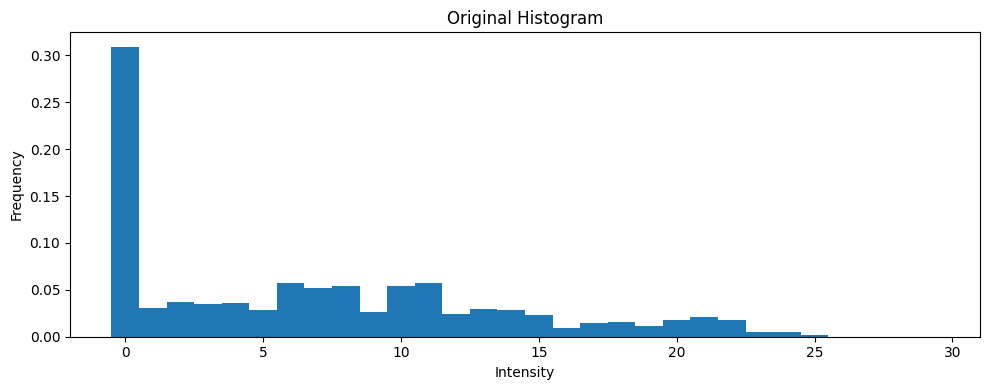

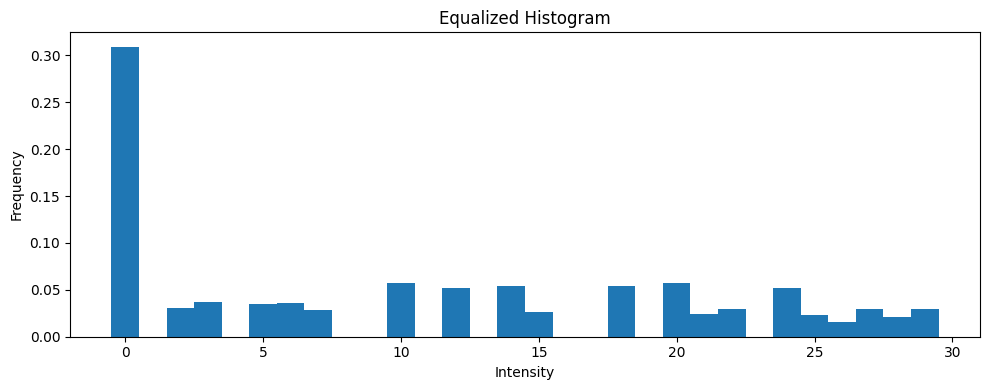

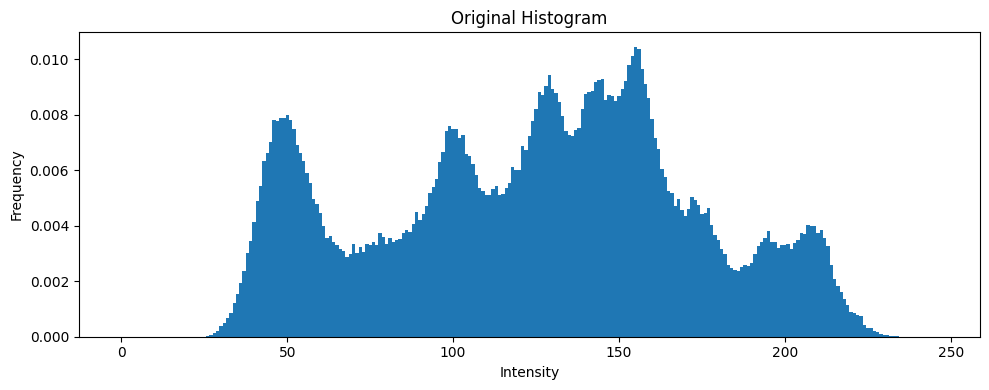

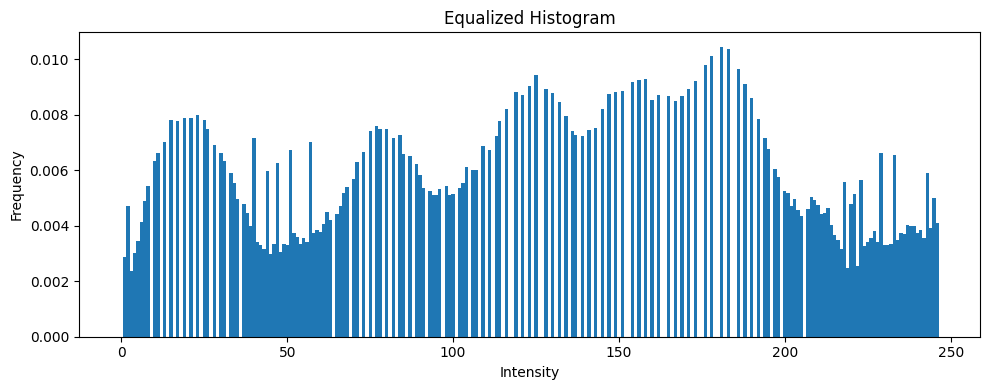

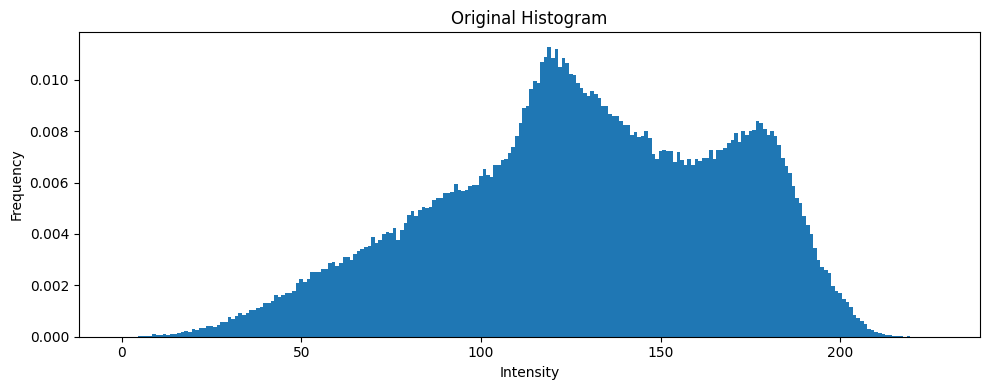

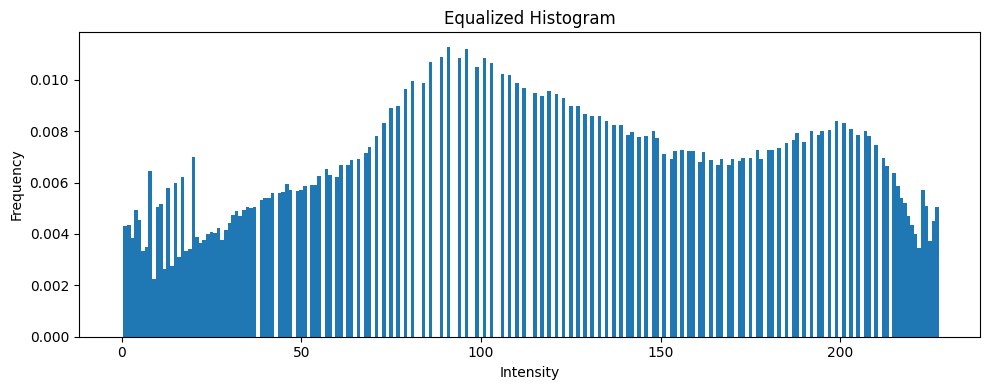

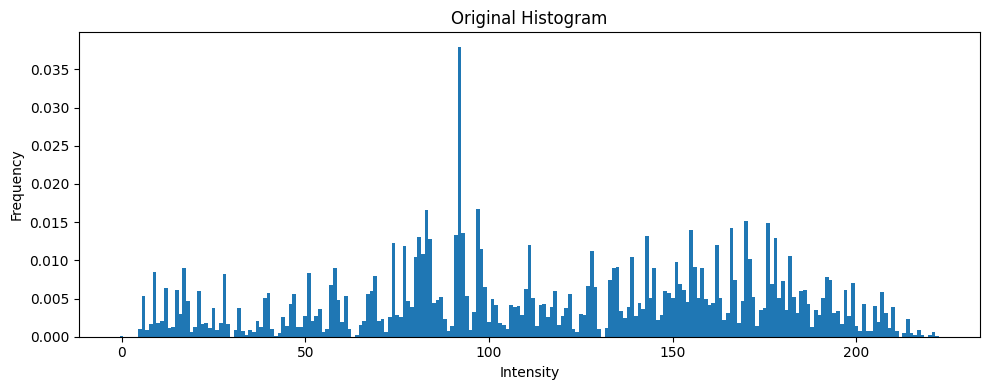

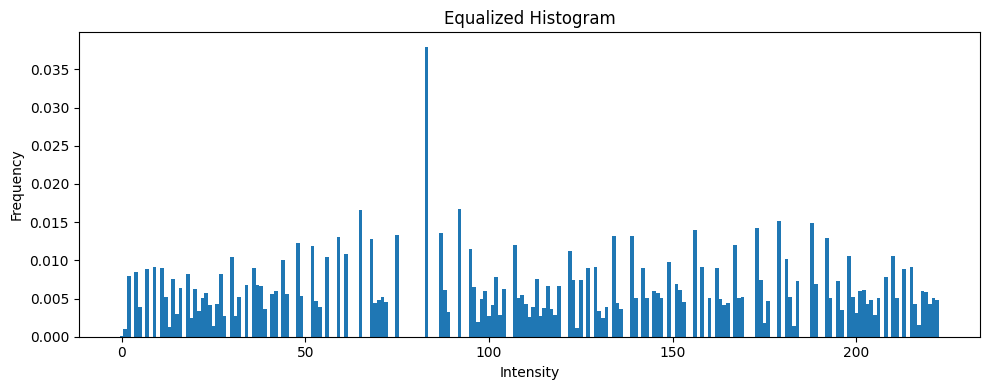

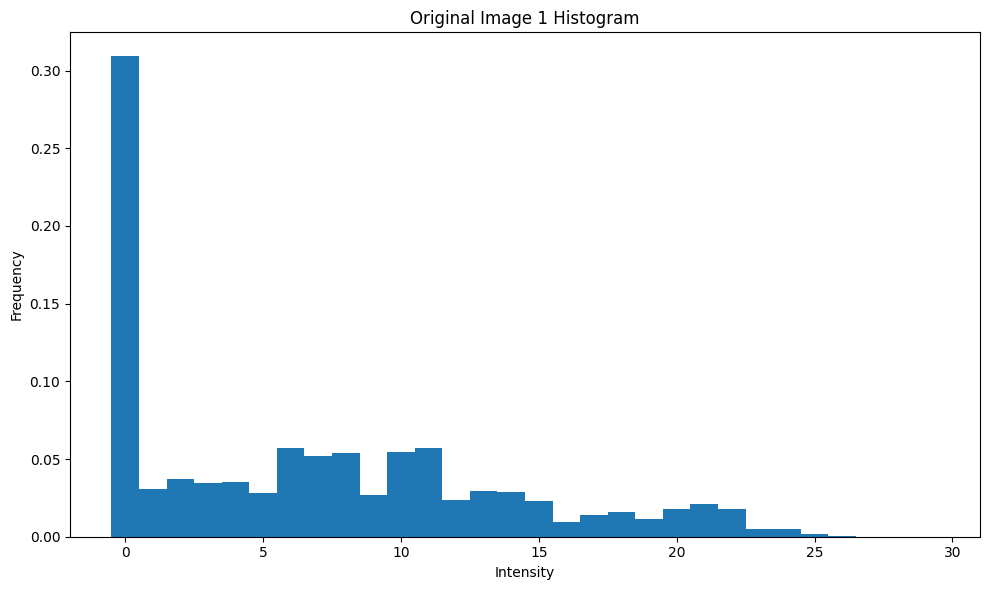

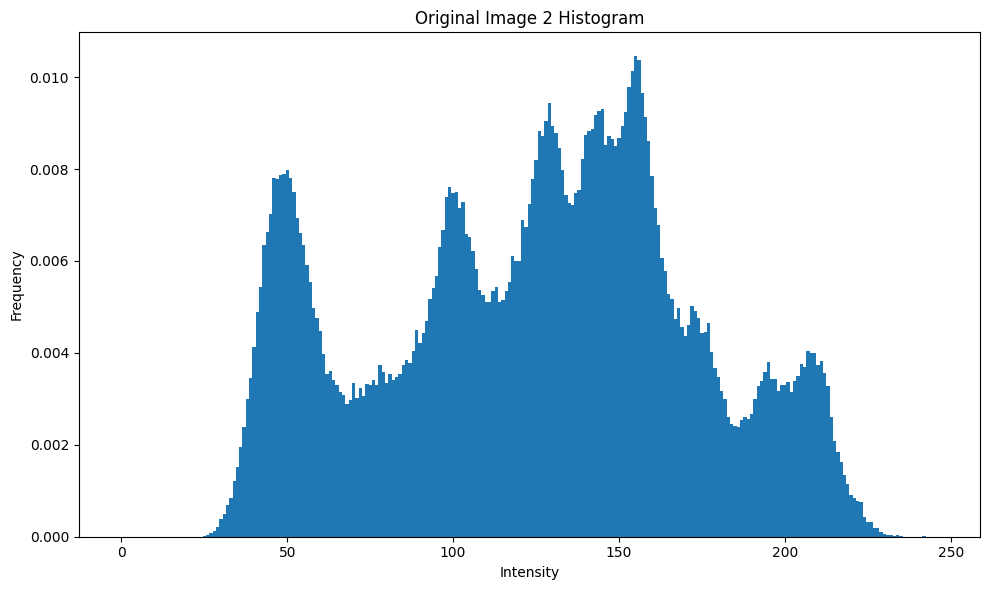

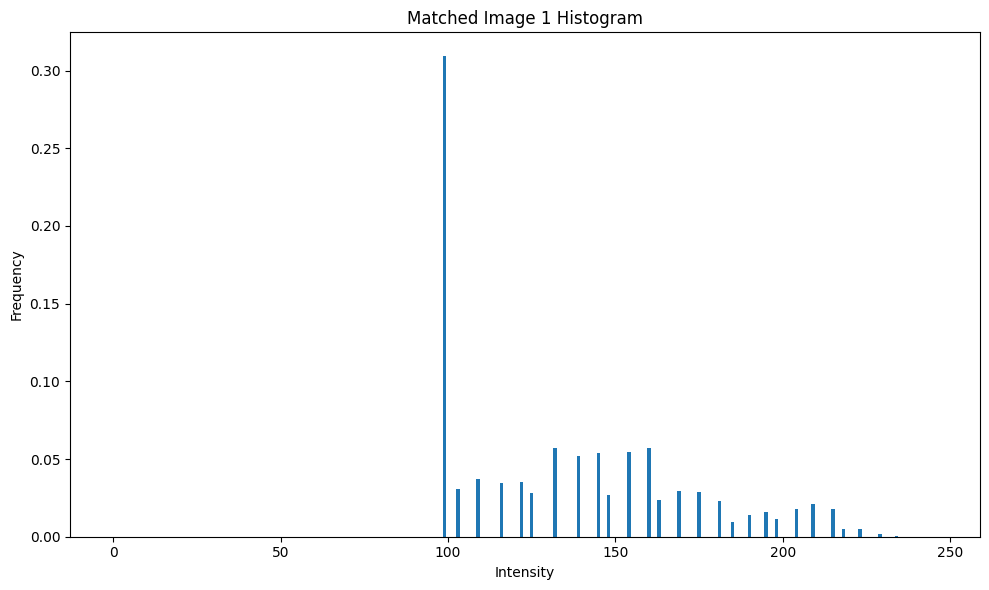

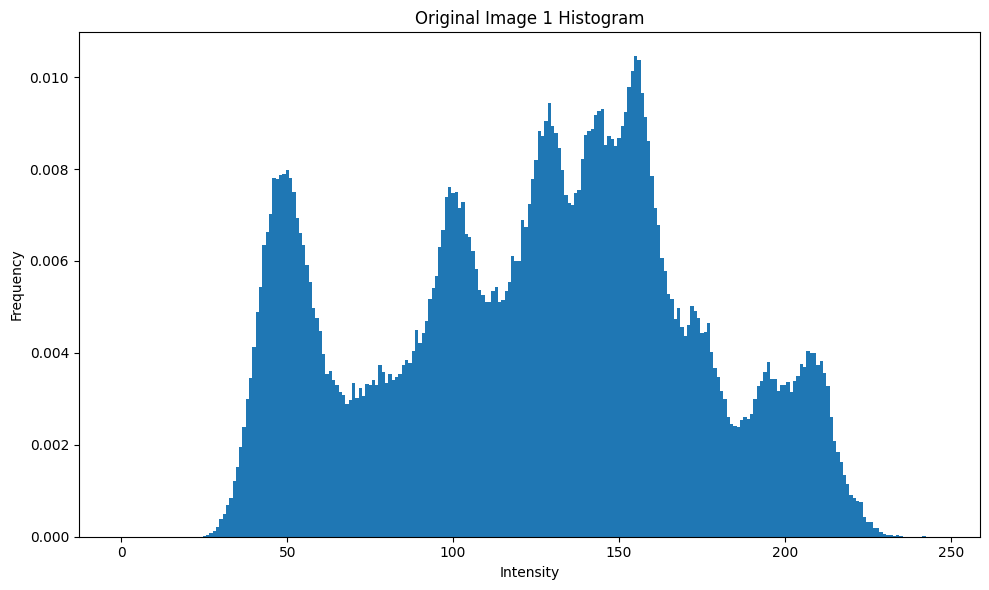

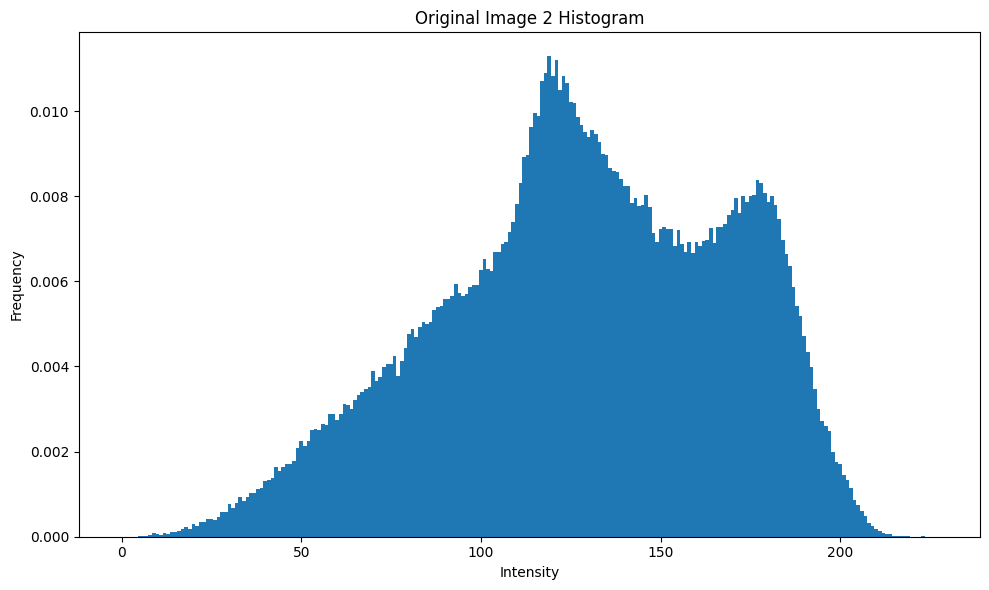

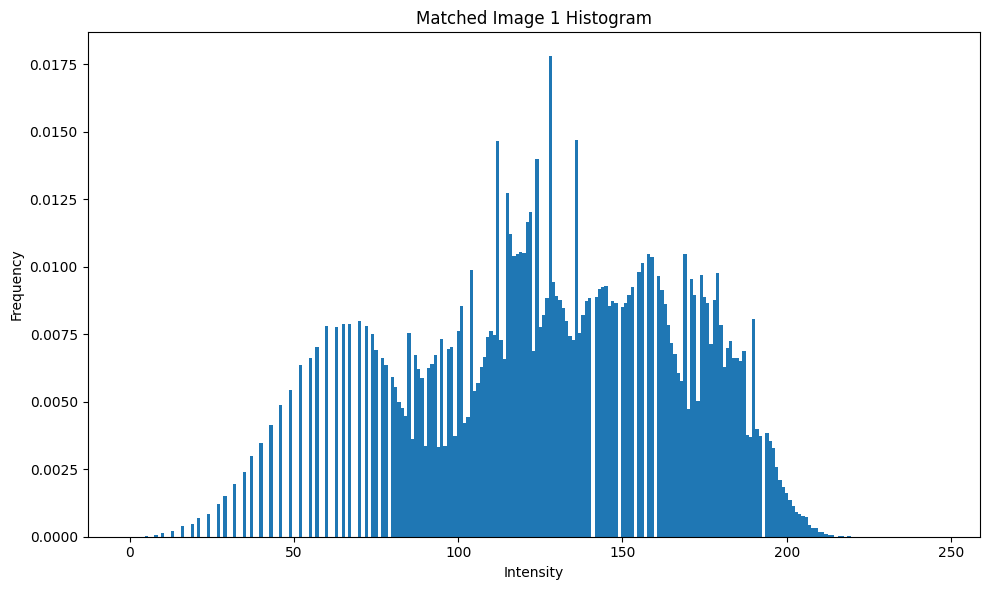

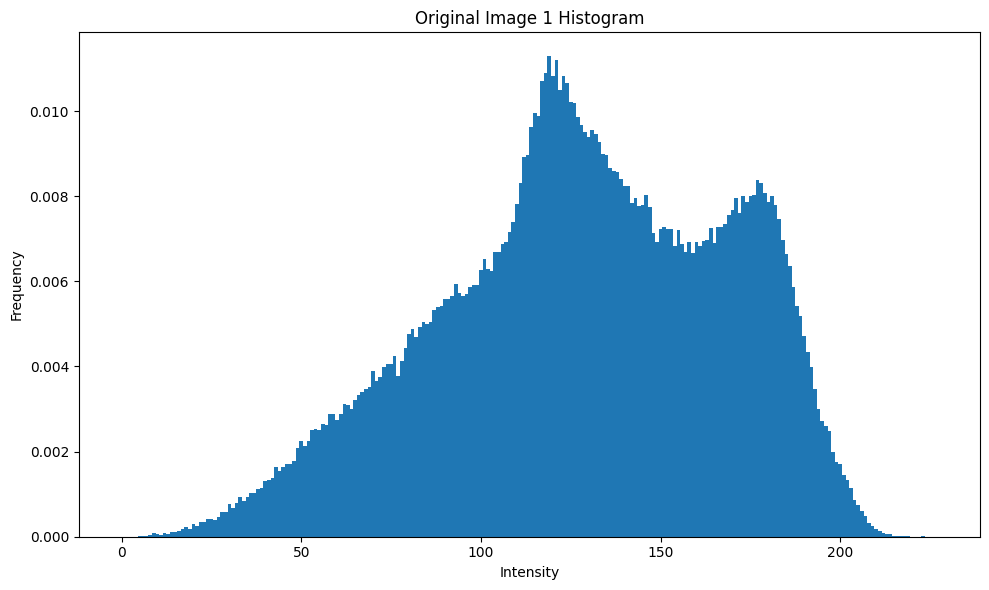

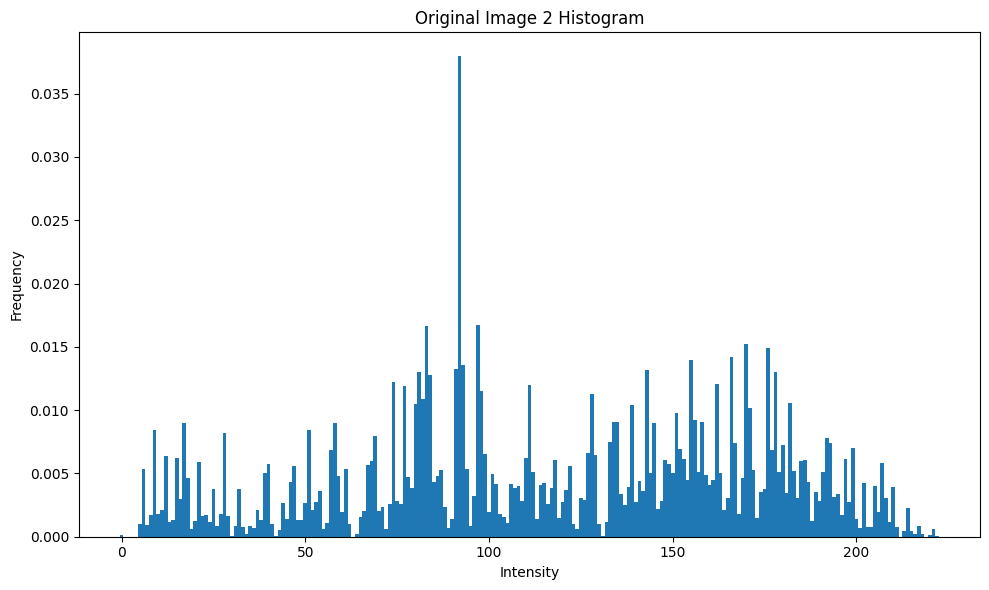

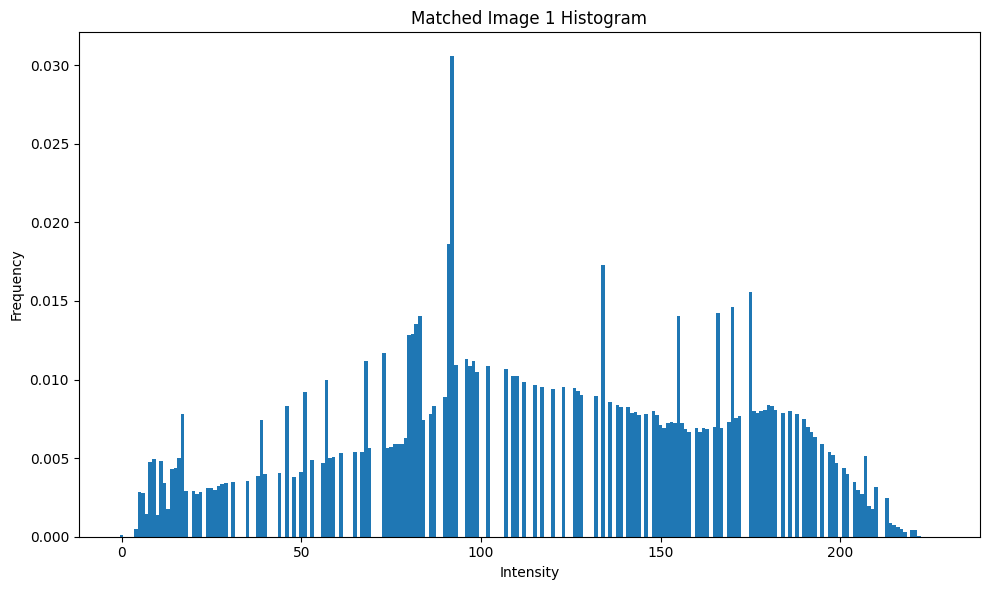

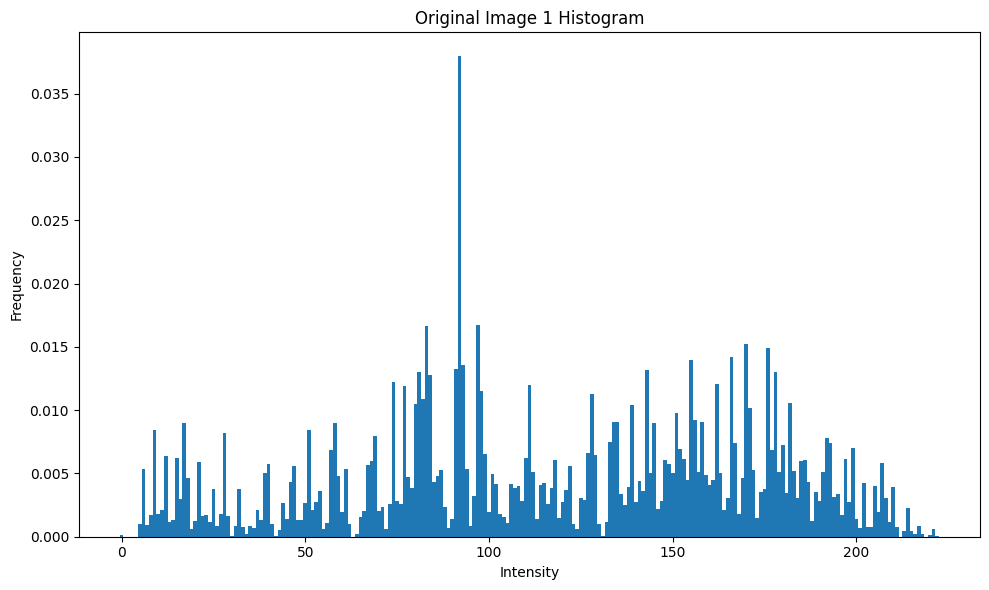

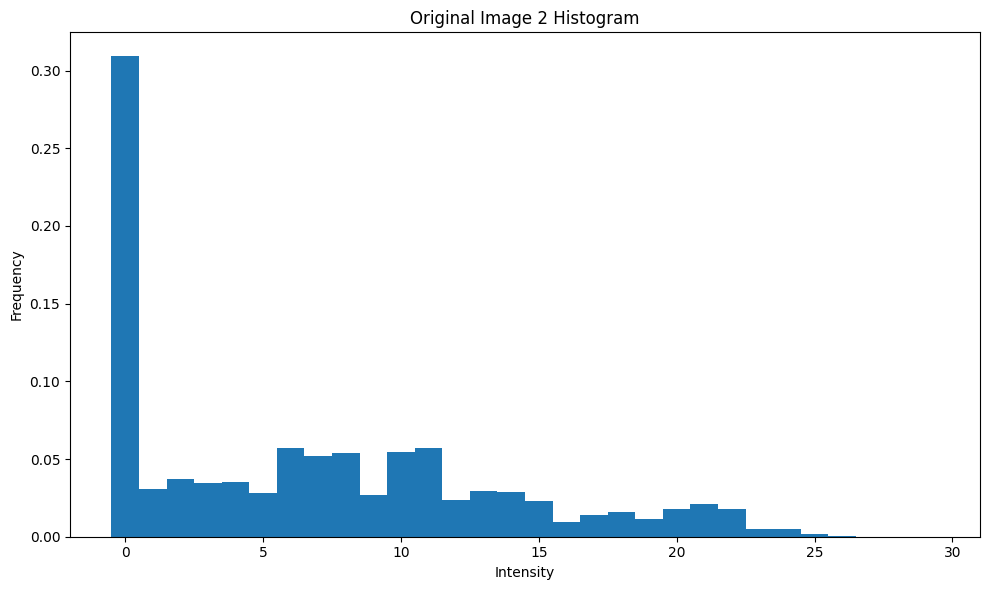

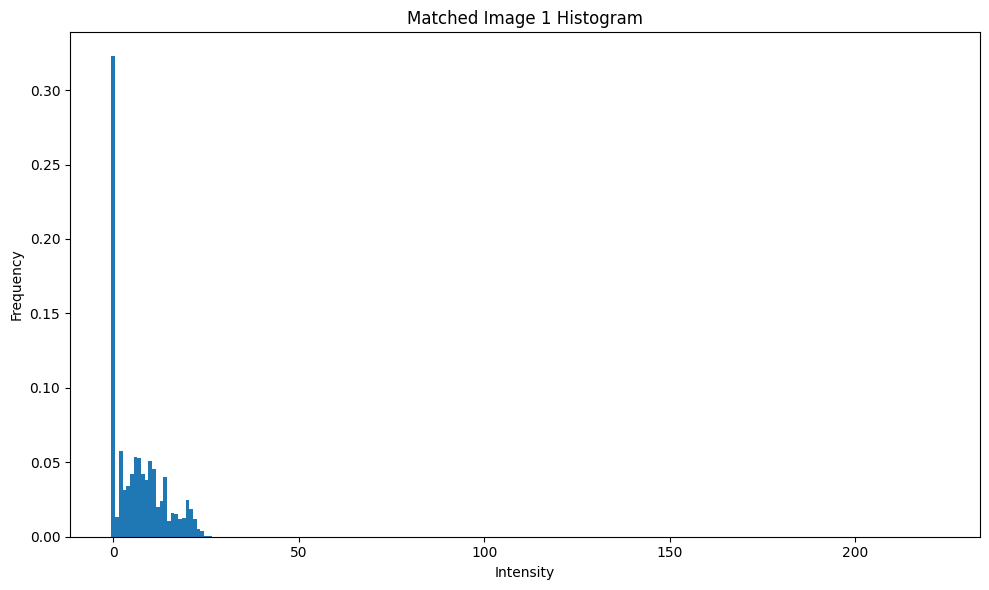

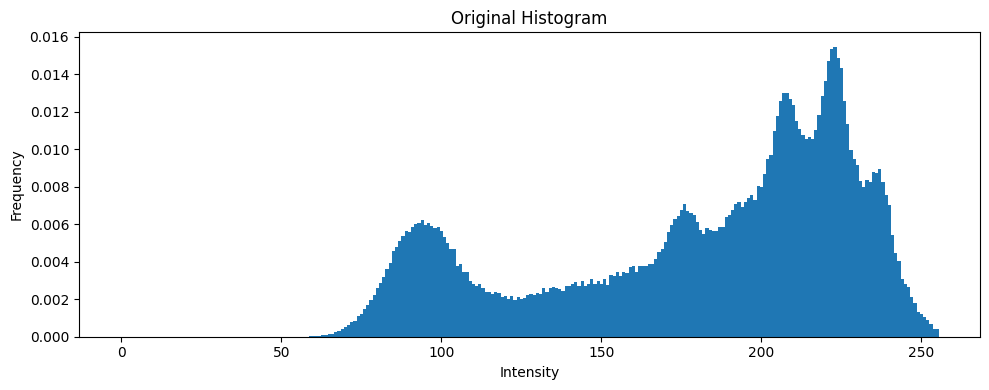

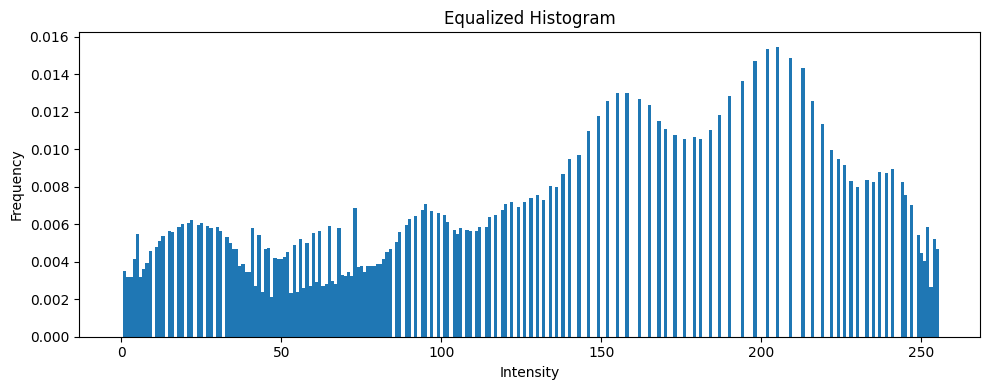

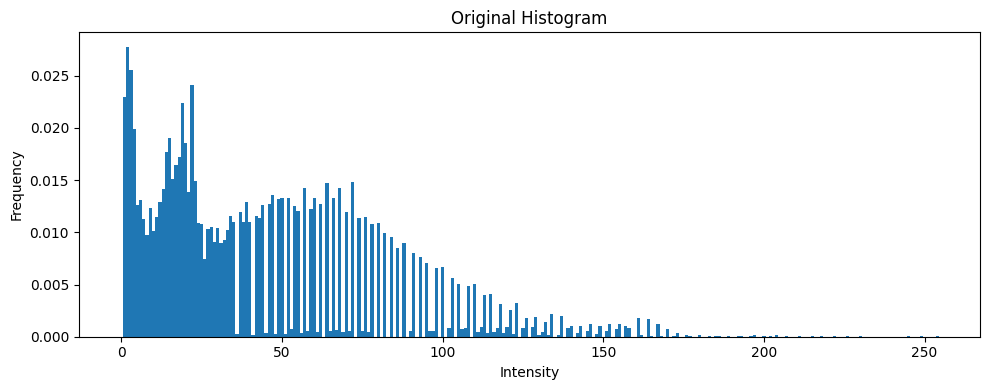

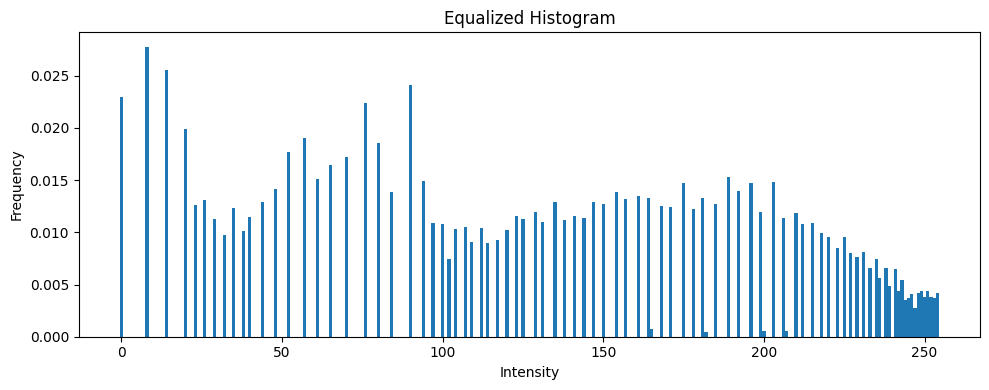

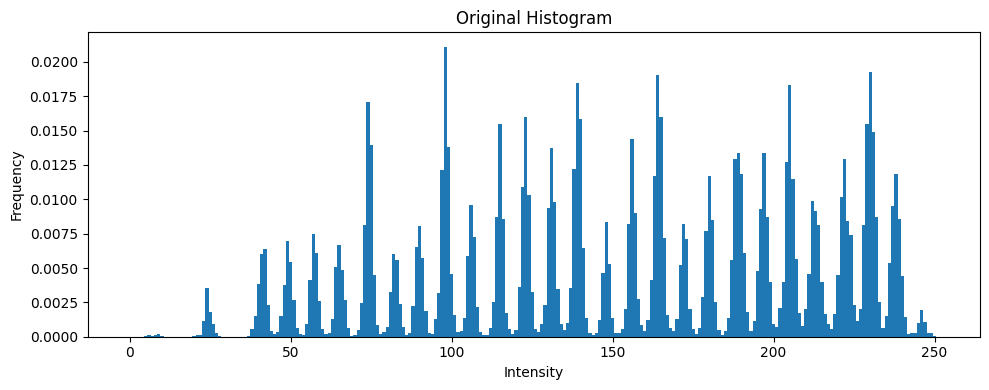

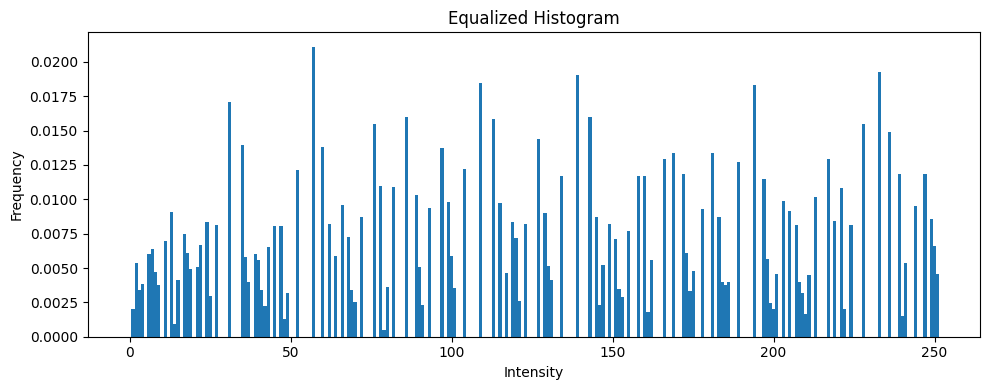

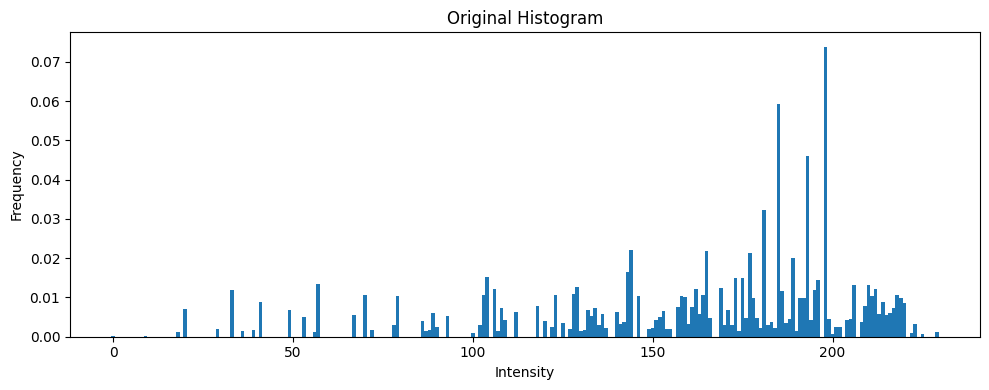

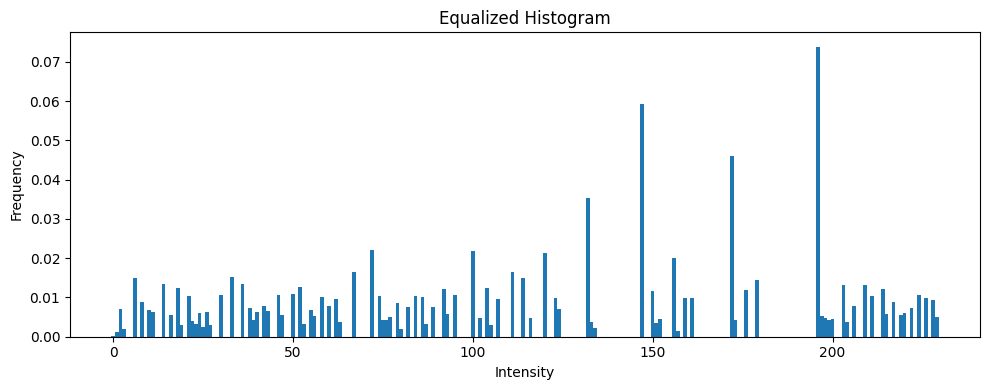

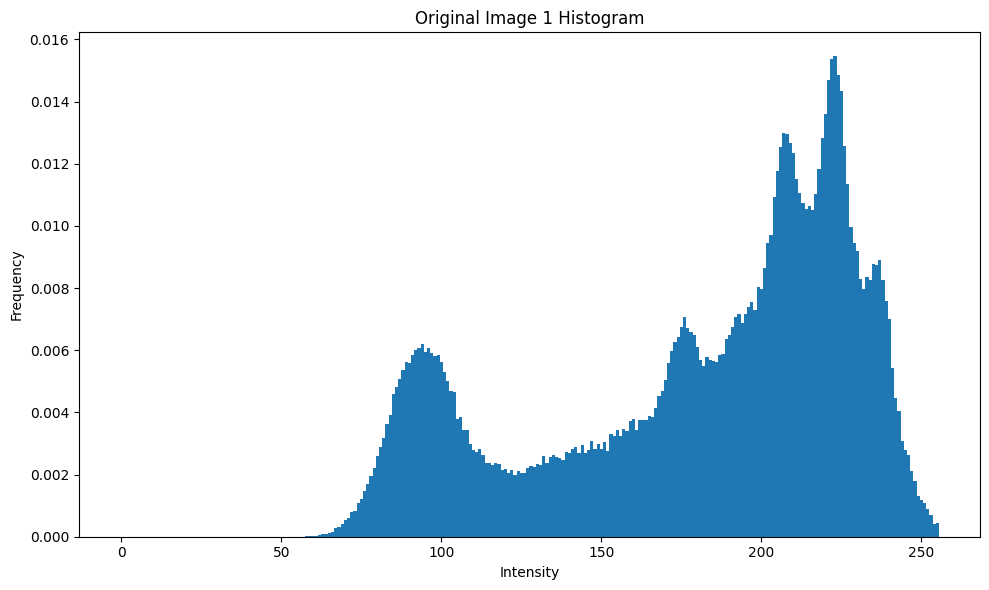

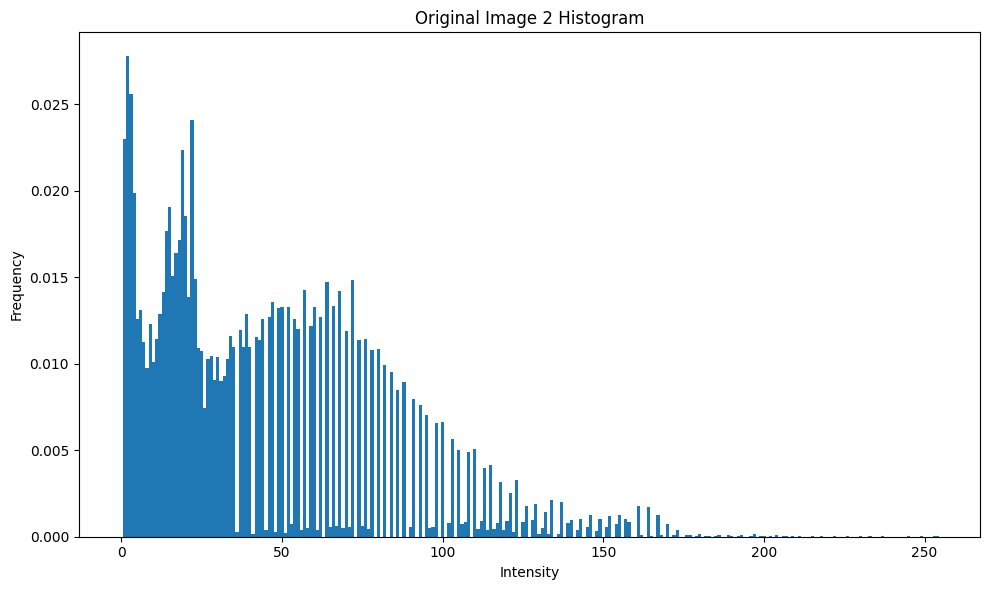

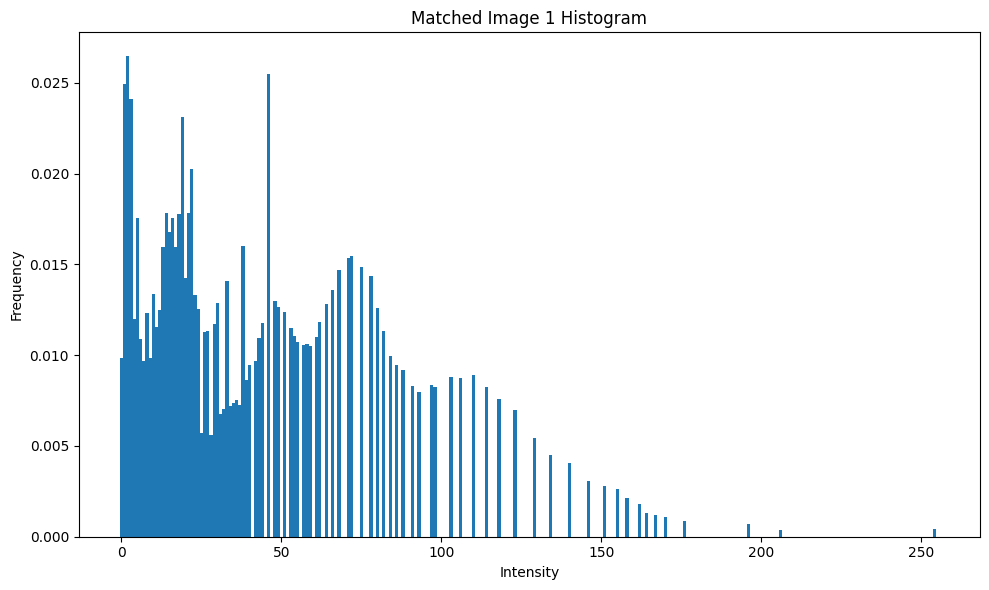

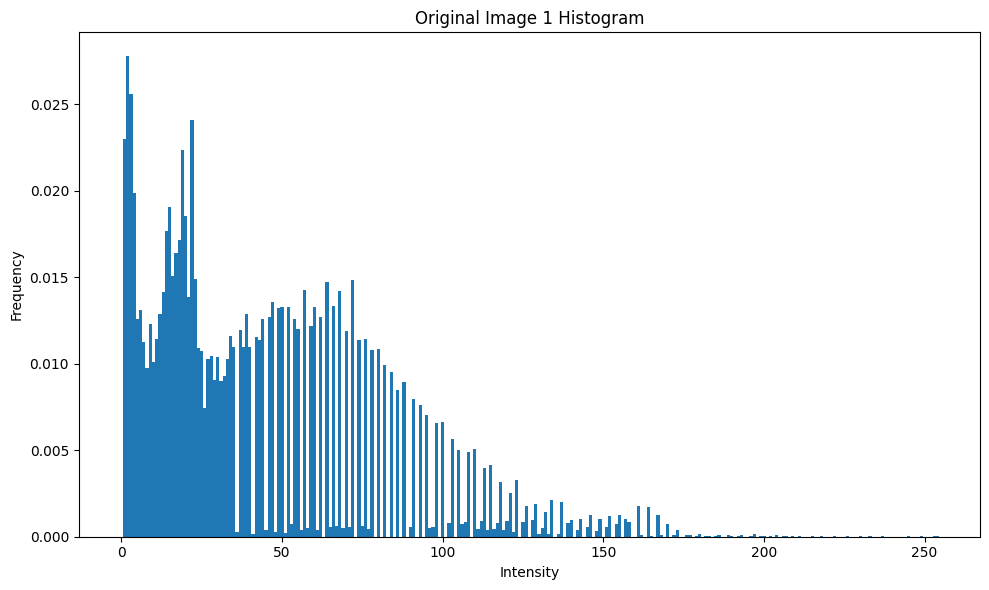

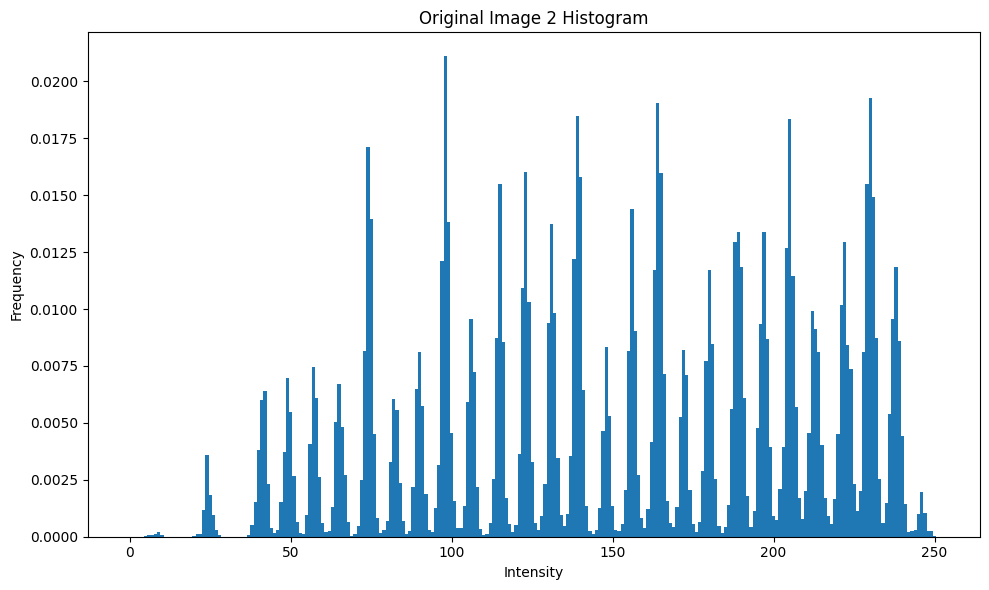

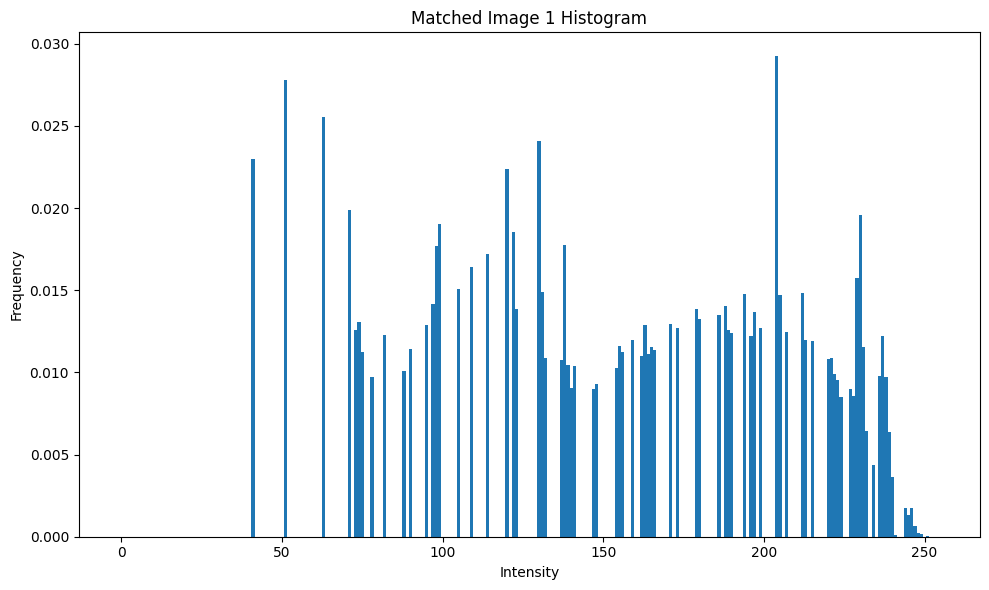

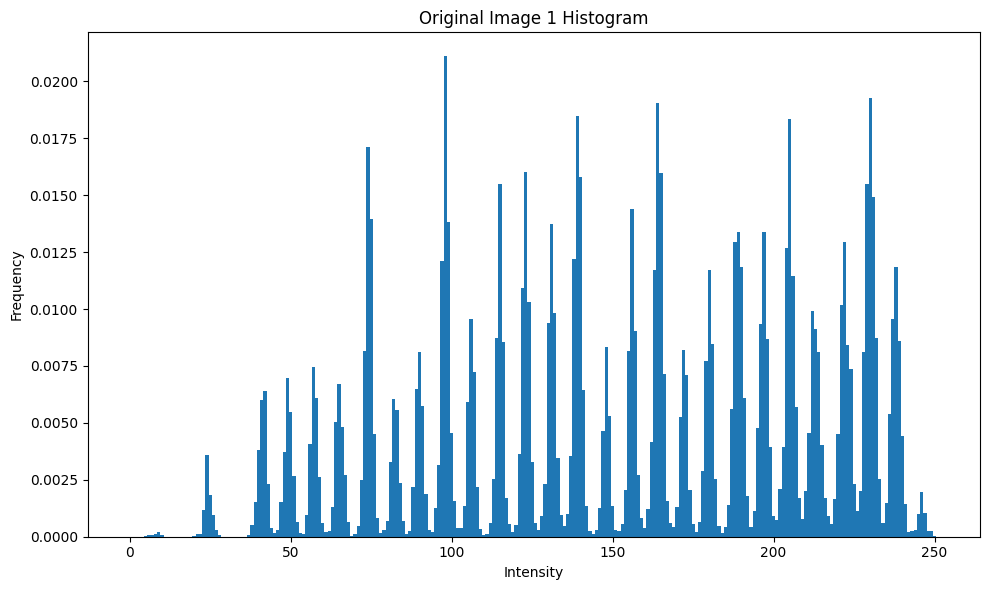

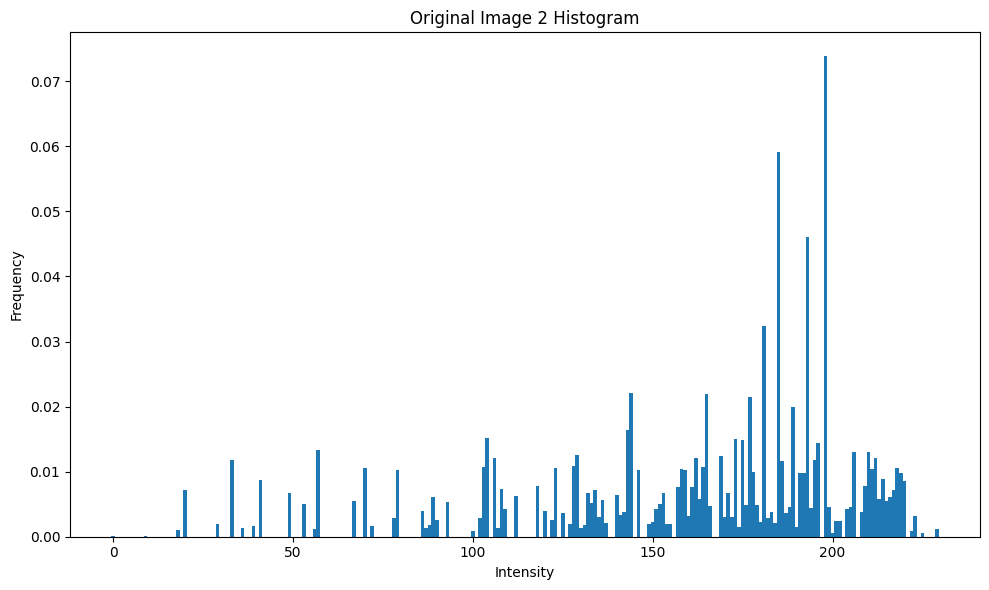

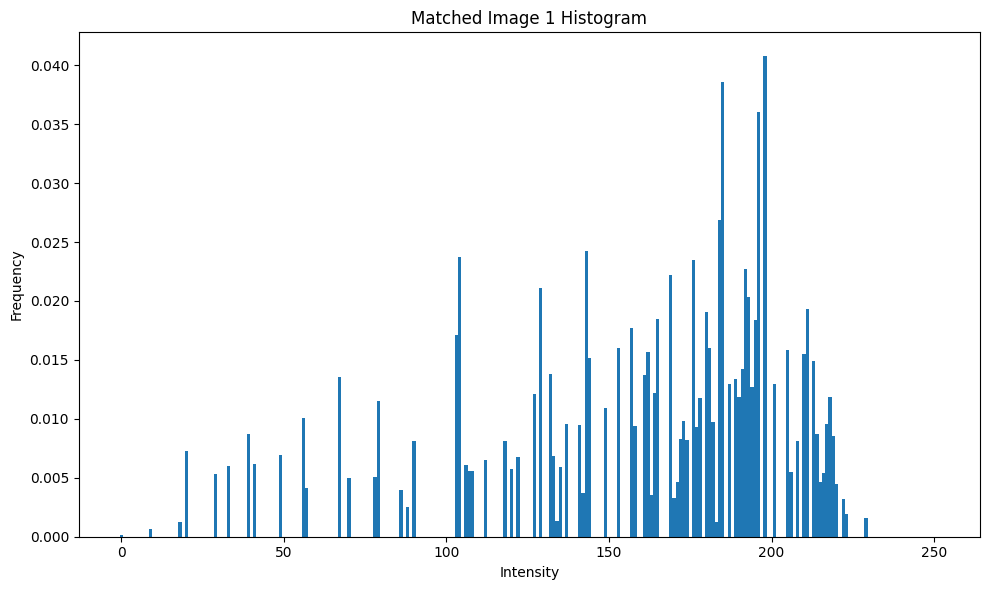

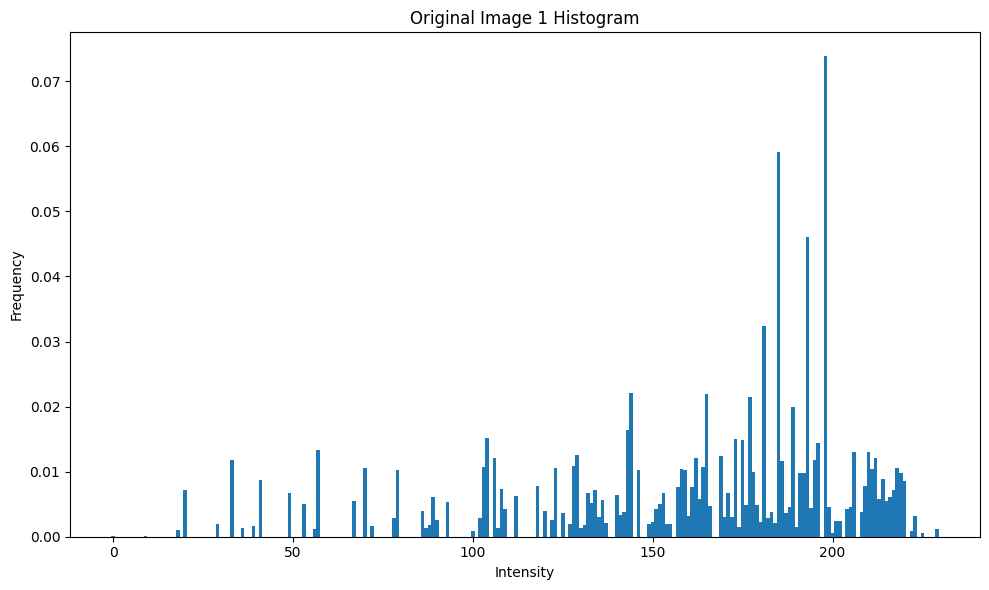

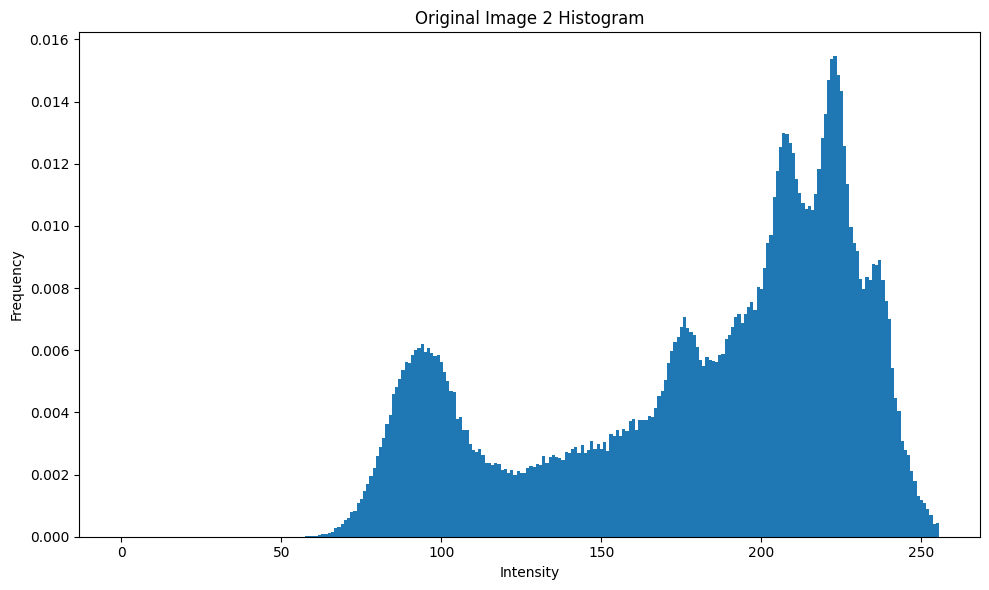

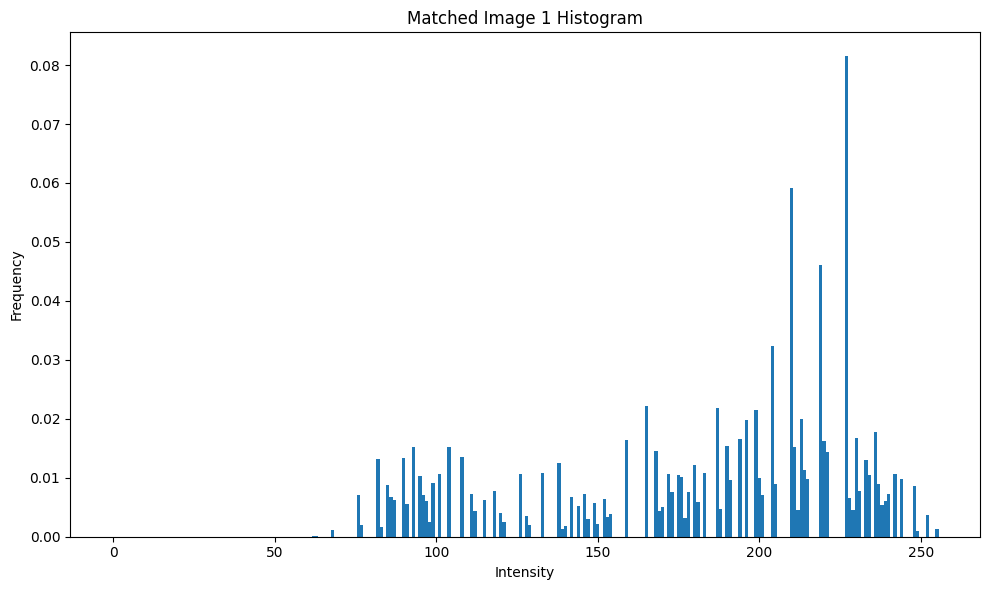

In [14]:
gray_images = ['/content/lena_gray_dark.jpg','/content/lena_gray_512.jpg','/content/mandril_gray.jpg','/content/peppers_gray.jpg']
color_images = ['/content/lena_color_512.jpg','/content/livingroom_dark.tiff','/content/mandril_color.jpg','/content/peppers_color.bmp']
for i in range(len(gray_images)):
  histogram_equalization_gray(gray_images[i])
for i in range(len(gray_images)):
  histogram_matching_gray(gray_images[i],gray_images[(i+1)%len(gray_images)])
for i in range(len(color_images)):
  histogram_equalization_RGB(color_images[i])
for i in range(len(color_images)):
  histogram_matching_RGB(color_images[i],color_images[(i+1)%len(color_images)])

In [15]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Main folder
base_folder = '/content/drive/MyDrive/Histogram_Processing'

# Main folders
equalized_folder = os.path.join(base_folder, 'Equalized')
matching_folder = os.path.join(base_folder, 'Matching')

os.makedirs(equalized_folder, exist_ok=True)
os.makedirs(matching_folder, exist_ok=True)


# ============================================================
# STORE EQUALIZATION RESULTS
# ============================================================

for image in gray_images + color_images:

    name, ext = os.path.splitext(image)
    image_name = os.path.basename(name)

    # Folder named after the input image
    folder = os.path.join(equalized_folder, image_name)
    os.makedirs(folder, exist_ok=True)

    # Input image
    shutil.copy(
        image,
        os.path.join(folder, os.path.basename(image))
    )

    # Equalized image
    equalized_image = name + '_equalized' + ext

    if os.path.exists(equalized_image):
        shutil.copy(
            equalized_image,
            os.path.join(folder, os.path.basename(equalized_image))
        )

    # Original histogram
    original_histogram = name + '_original_histogram.png'

    if os.path.exists(original_histogram):
        shutil.copy(
            original_histogram,
            os.path.join(folder, os.path.basename(original_histogram))
        )

    # Equalized histogram
    equalized_histogram = name + '_equalized_histogram.png'

    if os.path.exists(equalized_histogram):
        shutil.copy(
            equalized_histogram,
            os.path.join(folder, os.path.basename(equalized_histogram))
        )


# ============================================================
# STORE MATCHING RESULTS
# ============================================================

for images in [gray_images, color_images]:

    for i in range(len(images)):

        image1 = images[i]
        image2 = images[(i + 1) % len(images)]

        name1, ext1 = os.path.splitext(image1)
        name2, ext2 = os.path.splitext(image2)

        image1_name = os.path.basename(name1)
        image2_name = os.path.basename(name2)

        # Folder named image1 + image2
        pair_name = image1_name + '_' + image2_name

        folder = os.path.join(matching_folder, pair_name)
        os.makedirs(folder, exist_ok=True)

        # Input image 1
        shutil.copy(
            image1,
            os.path.join(folder, os.path.basename(image1))
        )

        # Input image 2
        shutil.copy(
            image2,
            os.path.join(folder, os.path.basename(image2))
        )

        # Matched image
        matched_image = name1 + '_matched' + ext1

        if os.path.exists(matched_image):
            shutil.copy(
                matched_image,
                os.path.join(folder, os.path.basename(matched_image))
            )

        # Image 1 histogram
        histogram1 = name1 + '_original1_histogram.png'

        if os.path.exists(histogram1):
            shutil.copy(
                histogram1,
                os.path.join(folder, os.path.basename(histogram1))
            )

        # Image 2 histogram
        histogram2 = name2 + '_original2_histogram.png'

        if os.path.exists(histogram2):
            shutil.copy(
                histogram2,
                os.path.join(folder, os.path.basename(histogram2))
            )

        # Matched histogram
        matched_histogram = name1 + '_matched_histogram.png'

        if os.path.exists(matched_histogram):
            shutil.copy(
                matched_histogram,
                os.path.join(folder, os.path.basename(matched_histogram))
            )


print("All input, equalized, matched images and histograms have been stored in Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All input, equalized, matched images and histograms have been stored in Google Drive.
